In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import dash
from dash import dcc, html

In [2]:
ruta=r"C:\python\archivos\earthquake.csv"
df = pd.read_csv(ruta)

In [3]:
df.head()

,Date & Time,Latitude,Longitude,Depth,Magnitude,Lands,Country
0,11/21/2023 16:36,38243.0,38808.0,7,1.0,EASTERN,TURKEY
1,11/21/2023 15:59,39134.0,29026.0,10,1.0,WESTERN,TURKEY
2,11/21/2023 13:00,39636.0,30104.0,7,1.0,WESTERN,TURKEY
3,11/20/2023 18:43,47368.0,6918.0,5,1.0,SWITZERLAND,SWITZERLAND
4,11/19/2023 10:48,37175.0,36892.0,7,1.0,CENTRAL,TURKEY


In [4]:
df["Date & Time"] = pd.to_datetime(df["Date & Time"])

In [5]:
df.head()

,Date & Time,Latitude,Longitude,Depth,Magnitude,Lands,Country
0,2023-11-21 16:36:00,38243.0,38808.0,7,1.0,EASTERN,TURKEY
1,2023-11-21 15:59:00,39134.0,29026.0,10,1.0,WESTERN,TURKEY
2,2023-11-21 13:00:00,39636.0,30104.0,7,1.0,WESTERN,TURKEY
3,2023-11-20 18:43:00,47368.0,6918.0,5,1.0,SWITZERLAND,SWITZERLAND
4,2023-11-19 10:48:00,37175.0,36892.0,7,1.0,CENTRAL,TURKEY


In [6]:
# Mapa Coropletico
"""
fig1 = px.choropleth(
    df,
    locations = "Country",
    locationmode="country names",
    color="Magnitude",
    hover_name="Country",
    projection="natural earth"
)

fig1.update_layout(
    title="Mapa Global de Terremotos segun magnitud"
)
"""

'\nfig1 = px.choropleth(\n    df,\n    locations = "Country",\n    locationmode="country names",\n    color="Magnitude",\n    hover_name="Country",\n    projection="natural earth"\n)\n\nfig1.update_layout(\n    title="Mapa Global de Terremotos segun magnitud"\n)\n'

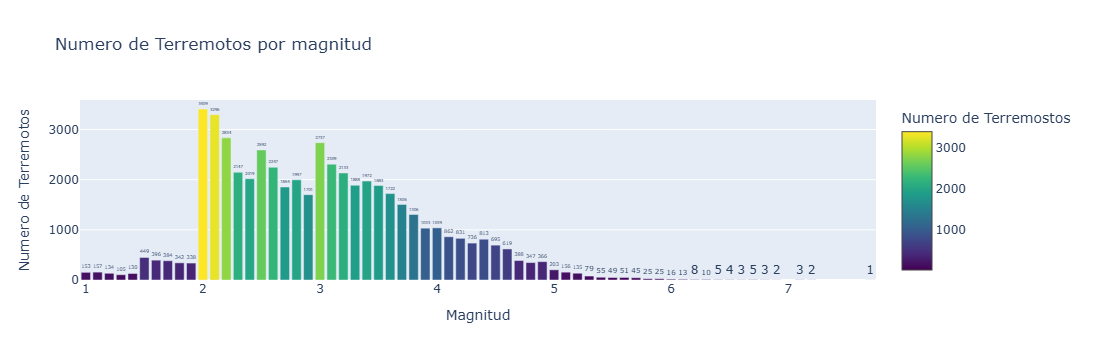

In [9]:
# grafico de barras
magnitudes = df["Magnitude"].value_counts().sort_index()
fig2 = go.Figure(
    go.Bar(
        x=magnitudes.index,
        y=magnitudes.values,
        marker=dict(
            color=magnitudes.values,
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Numero de Terremostos")
        ),
        text=magnitudes.values,
        textposition="outside"
    )
)

fig2.update_layout(
    title="Numero de Terremotos por magnitud",
    xaxis_title="Magnitud",
    yaxis_title="Numero de Terremotos"
)

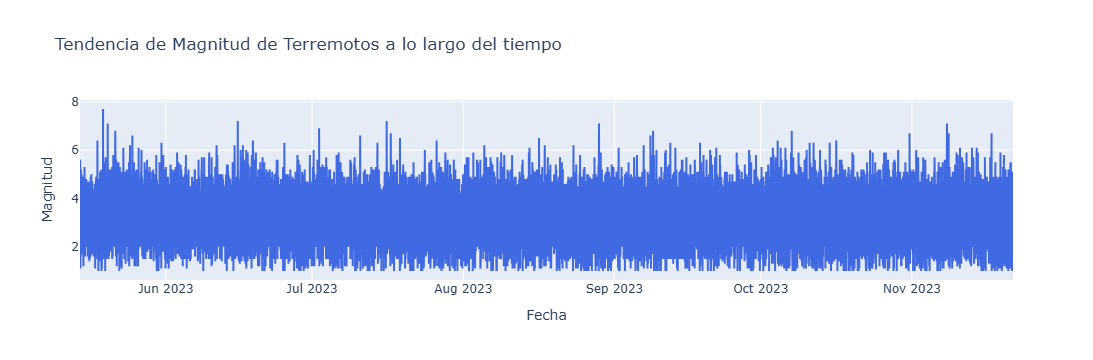

In [11]:
# Grafico de lineas
df.sort_values("Date & Time", inplace=True)
fig3 = go.Figure(
    go.Scatter(
        x=df["Date & Time"],
        y=df["Magnitude"],
        mode="lines",
        line=dict(
            width=2,
            color="royalblue"
        ),
        text=df["Magnitude"],
        textposition="top center"
    )
)

fig3.update_layout(
    title="Tendencia de Magnitud de Terremotos a lo largo del tiempo",
    xaxis_title="Fecha",
    yaxis_title="Magnitud"
)

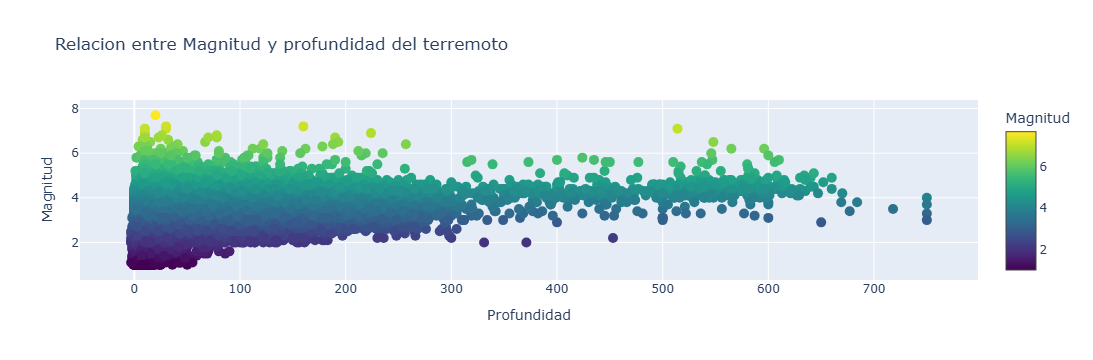

In [13]:
fig4 = go.Figure(
    go.Scatter(
        x=df["Depth"],
        y=df["Magnitude"],
        mode="markers",
        marker=dict(
            size=10,
            color=df["Magnitude"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Magnitud")
        ),
        text=df["Magnitude"],
        hoverinfo="text+x+y"
    )
)

fig4.update_layout(
    title="Relacion entre Magnitud y profundidad del terremoto",
    xaxis_title="Profundidad",
    yaxis_title="Magnitud"
)

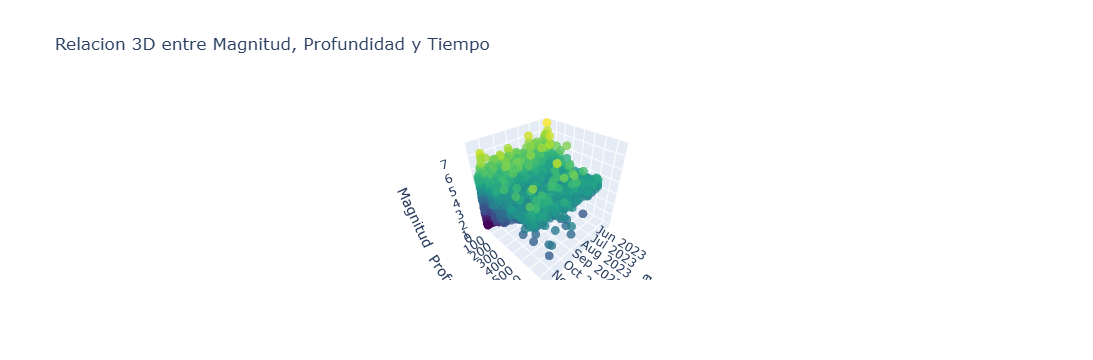

In [15]:
fig6 = go.Figure(
    go.Scatter3d(
        x=df["Date & Time"],
        y=df["Depth"],
        z=df["Magnitude"],
        mode="markers",
        marker=dict(
            size=5,
            color=df["Magnitude"],
            colorscale="Viridis",
            opacity=0.8
        )
    )
)

fig6.update_layout(
    title="Relacion 3D entre Magnitud, Profundidad y Tiempo",
    scene=dict(
        xaxis_title="Fecha",
        yaxis_title="Profundidad",
        zaxis_title="Magnitud"
    )
)

In [17]:
# Se inicia la aplicacion con dash
app = dash.Dash(__name__)

In [21]:
app.layout=html.Div(
    [
        html.H1("DashBoard de Terremotos"),
        dcc.Graph(id="mapa-coropleto", figure=fig2),
        dcc.Graph(id="grafico-barras", figure=fig2),
        dcc.Graph(id="grafico-lineas", figure=fig3),
        dcc.Graph(id="grafico-dispersion", figure=fig4),
        dcc.Graph(id="grafico-3d", figure=fig6)
    ]
)

In [23]:
if __name__ == "__main__":
    app.run(sebug=True)